In [1]:
import os, time
def elapsed():
    return time.strftime("%H:%M:%S")
import matplotlib.pyplot as plt

In [2]:
from PIL import Image
import numpy as np


path_data = r'/home/d.golomolzin/.cache/kagglehub/datasets/balraj98/massachusetts-roads-dataset/versions/1/tiff'
X_train_path = os.path.join(path_data, 'train')
y_train_path = os.path.join(path_data, 'train_labels')
X_valid_path = os.path.join(path_data, 'val')
y_valid_path = os.path.join(path_data, 'val_labels')
# X_test_path  = os.path.join(path_data, 'test')
# y_test_path  = os.path.join(path_data, 'test_labels')

import albumentations as A
from albumentations.pytorch import ToTensorV2

class DataSet:
    '''Датасет дорог по переданным путям папок'''
    
    def __init__(self, X_path: str, y_path: str):
        shape_image = (512, 512)
        self.X_pathes, self.y_pathes = self.unpack(X_path, y_path)
       
        self.transform = A.Compose([
            A.Resize(*shape_image),
            # A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.GaussianBlur(blur_limit=(3,7), p=0.2),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.Rotate(limit=15, p=0.5),
            A.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]), # type: ignore
            ToTensorV2()
        ])

    def unpack(self, X_path: str, y_path: str):
        '''Вытаскивает пути к изображениям'''
        X, y = [], []
        for img_path, lbl_path in zip(sorted(os.listdir(X_path)), sorted(os.listdir(y_path))):
            X.append(os.path.join(X_path, img_path))
            y.append(os.path.join(y_path, lbl_path))
        return X, y
    
    def __getitem__(self, key):

        image = np.array(Image.open(self.X_pathes[key]).convert('RGB'))
        label = np.array(Image.open(self.y_pathes[key]).convert('L'))
        
        label[np.all(image == 255, axis=-1)] = 0

        aug = self.transform(image=image, mask=label)

        image_t = aug['image']
        label_t = aug['mask']

        return image_t, (label_t > 0.5).long()

    def __len__(self):
        return len(self.y_pathes)

/home/d.golomolzin/.venv/lib/python3.10/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error _ssl.c:990: The handshake operation timed out>
  data = fetch_version_info()


In [3]:
from torch.utils.data import DataLoader


batch_size = 32

trainloader = DataLoader(
    DataSet(X_train_path, y_train_path),
    batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=False)
validloader = DataLoader(
    DataSet(X_valid_path, y_valid_path),
    batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=False)
it = iter(trainloader)

In [4]:
# import cv2

# # image = Image.open(trainloader.dataset.X_pathes[0]).convert('RGB')
# image = cv2.imread(trainloader.dataset.X_pathes[0])
# plt.imshow(image)

In [5]:
# image = next(it)
# # print(image[0][0])
# plt.imshow(image[0][0].permute(1, 2, 0))

In [6]:
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
import torchvision.transforms as tt


device = torch.device('cuda')
model = smp.Unet(encoder_name='resnet50', encoder_weights='imagenet')

model = nn.DataParallel(model).to(device)

optimizer = torch.optim.AdamW(params=model.parameters(), lr=3e-4, weight_decay=1e-5)

dice_func = smp.losses.DiceLoss(mode='binary')
# bce_func = smp.losses.FocalLoss(mode='binary')
bce_func = torch.nn.BCEWithLogitsLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

In [8]:
train_samples = len(trainloader.dataset)
valid_samples = len(validloader.dataset)
iouses, dices, bceses, accses = [], [], [], []
train_losses, valid_losses = [], []

EPOCH = 50
# NUM_UPDATE = 5
# koef = 0.8
# step_koef = (1 - koef) / (EPOCH//NUM_UPDATE)
model.train()
best_iou = -1
for epoch in range(EPOCH):
    
    curr_loss = 0.0
    for xb, yb in trainloader:

        optimizer.zero_grad()

        xb, yb = xb.to(device), yb.to(device)
        yb_long = yb.unsqueeze(1)
        yb_float = yb_long.float()
        bs = xb.size(0)

        y_pred = model(xb)

        # loss = dice_func(torch.sigmoid(y_pred), yb) * koef + bce_func(y_pred, yb) * (1 - koef)
        loss = dice_func(torch.sigmoid(y_pred), yb_float) + bce_func(y_pred, yb_float)

        loss.backward()

        curr_loss += loss.item() * bs

        optimizer.step()

    train_losses.append(curr_loss/train_samples)

    # валидация
    model.eval()
    with torch.no_grad():

        iou, dice, bce, acc, curr_loss = .0, .0, .0, .0, .0

        for xb,yb in validloader:

            xb,yb = xb.to(device), yb.to(device)
            yb_long = yb.unsqueeze(1)
            yb_float = yb_long.float()
            bs = xb.size(0)
            
            y_pred = model(xb)
            bce_val = bce_func(y_pred, yb_float)

            tp, fp, fn, tn = smp.metrics.get_stats(torch.sigmoid(y_pred), yb_long, mode='binary', threshold=.5)

            iou_val  = smp.metrics.iou_score(tp, fp, fn, tn).mean() 
            dice_val = smp.metrics.f1_score(tp, fp, fn, tn).mean()
            acc_val  = smp.metrics.accuracy(tp, fp, fn, tn).mean()

            iou += iou_val .item()* bs
            dice += dice_val.item() * bs
            acc += acc_val.item() * bs
            bce += bce_val.item() * bs

            # loss = dice_func(torch.sigmoid(y_pred), yb) * koef + bce_func(y_pred, yb) * (1 - koef)
            loss = dice_func(torch.sigmoid(y_pred), yb_float) + bce_func(y_pred, yb_float)

            curr_loss += loss.item() * bs

        av_iou = iou/valid_samples
        av_dice = dice/valid_samples
        av_bce = bce/valid_samples
        av_acc = acc/valid_samples
        av_loss = curr_loss/valid_samples

        iouses.append(av_iou)
        dices.append(av_dice)
        bceses.append(av_bce)
        accses.append(av_acc)

        valid_losses.append(av_loss)

        print(f'Epoch: [ {epoch+1:^2} / {EPOCH} ]   time: {elapsed()}')
        print(f'  all: {av_loss:.4f}, iou: {av_iou:.4f}, dice: {av_dice:.4f}, bce: {av_bce:.4f}, acc: {av_acc:.4f}')

        if av_iou > best_iou:
            torch.save(model.state_dict(), 'best_model.pth')
            best_iou = av_iou
            print(f'  Сохранена модель {epoch+1} эпохи')
    model.train()
    scheduler.step(av_iou)

Epoch: [ 1  / 50 ]   time: 12:37:29
  all: 1.1667, iou: 0.0051, dice: 0.0101, bce: 0.2912, acc: 0.9311
  Сохранена модель 1 эпохи
Epoch: [ 2  / 50 ]   time: 12:37:53
  all: 1.0808, iou: 0.0819, dice: 0.1443, bce: 0.2094, acc: 0.9337
  Сохранена модель 2 эпохи
Epoch: [ 3  / 50 ]   time: 12:38:14
  all: 1.0573, iou: 0.2650, dice: 0.4122, bce: 0.1915, acc: 0.9392
  Сохранена модель 3 эпохи
Epoch: [ 4  / 50 ]   time: 12:38:38
  all: 1.1269, iou: 0.2665, dice: 0.4105, bce: 0.2599, acc: 0.9377
  Сохранена модель 4 эпохи
Epoch: [ 5  / 50 ]   time: 12:39:00
  all: 1.0610, iou: 0.2989, dice: 0.4508, bce: 0.1958, acc: 0.9428
  Сохранена модель 5 эпохи
Epoch: [ 6  / 50 ]   time: 12:39:23
  all: 1.0140, iou: 0.3848, dice: 0.5525, bce: 0.1533, acc: 0.9443
  Сохранена модель 6 эпохи
Epoch: [ 7  / 50 ]   time: 12:39:47
  all: 1.0049, iou: 0.3903, dice: 0.5585, bce: 0.1456, acc: 0.9452
  Сохранена модель 7 эпохи
Epoch: [ 8  / 50 ]   time: 12:40:09
  all: 1.0123, iou: 0.3697, dice: 0.5331, bce: 0.1514,

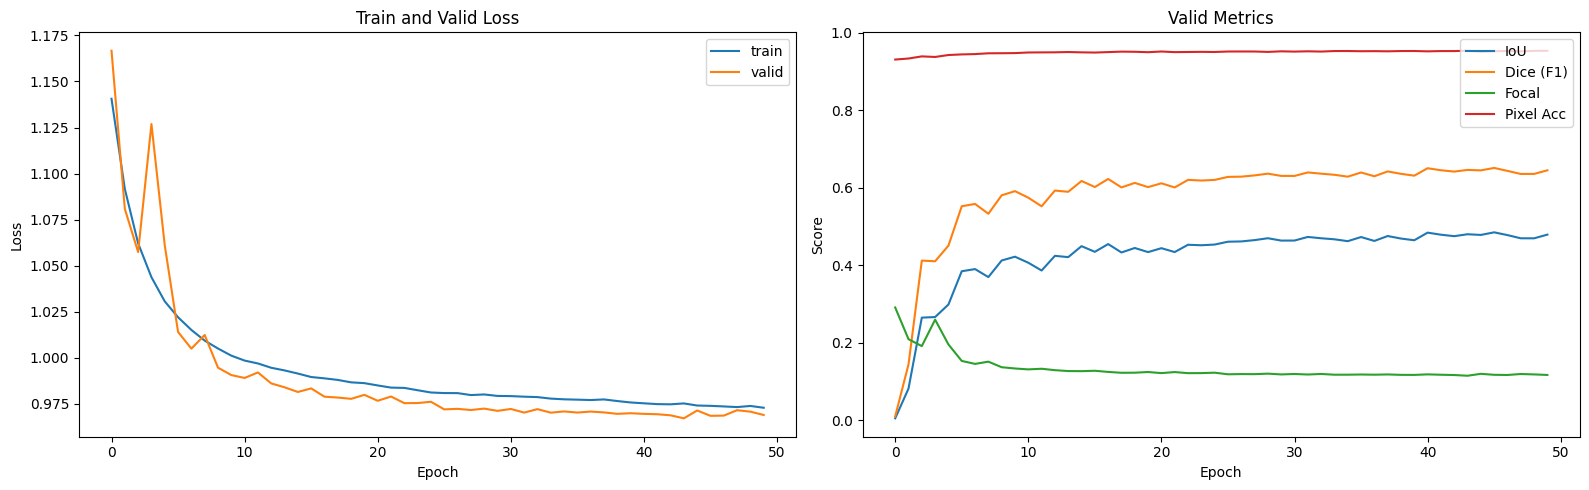

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].set_title('Train and Valid Loss')
ax[0].plot(train_losses, label='train')
ax[0].plot(valid_losses, label='valid')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[1].set_title('Valid Metrics')
ax[1].plot(iouses, label='IoU')
ax[1].plot(dices, label='Dice (F1)')
ax[1].plot(bceses, label='Focal')
ax[1].plot(accses, label='Pixel Acc')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Score')
ax[1].legend()

plt.tight_layout()

In [ ]:
# import matplotlib.pyplot as plt
# import torch
# import numpy as np


# def visualize_results(model, loader, device, num_samples):
#     """
#     Визуализирует результаты работы модели.
#     model: обученная модель
#     loader: DataLoader (лучше validloader или testloader)
#     device: устройство (cuda/cpu)
#     num_samples: сколько примеров показать
#     """
#     model.eval() # Режим оценки
    
#     # Берем один батч данных
#     with torch.no_grad():
#         for xb, yb in loader:
#             # Ограничиваем количество примеров, если в батче больше
#             xb = xb[:num_samples].to(device)
#             yb = yb[:num_samples].to(device)
            
#             # Предсказание
#             # preds = ///////////////model(xb)
            
#             # Применяем порог 0.5 для получения бинарной маски (0 или 1)
#             # preds уже имеют sigmoid на выходе, так что это вероятности
#             pred_masks = (preds > 0.5).float()
            
#             # Переводим все на CPU и в numpy для отрисовки
#             xb_cpu = xb.cpu()
#             yb_cpu = yb.cpu()
#             pred_masks_cpu = pred_masks.cpu()
            
#             break # Берем только первый батч
            
#     # Настройки для отрисовки
#     fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    
#     # Если показываем всего 1 пример, axes не будет массивом, исправляем
#     if num_samples == 1:
#         axes = axes.reshape(1, -1)

#     # Обратная нормализация изображений (чтобы они выглядели нормально, а не серыми)
#     mean = np.array([0.485, 0.456, 0.406])
#     std = np.array([0.229, 0.224, 0.225])

#     for i in range(num_samples):
#         # 1. Обработка изображения
#         img = xb_cpu[i].permute(1, 2, 0).numpy()
#         img = img * std + mean # Инвертируем нормализацию ImageNet
#         img = np.clip(img, 0, 1) # Обрезаем значения от 0 до 1
        
#         # 2. Обработка масок (берем первый канал [0], так как у нас 1 класс)
#         true_mask = yb_cpu[i, 0].numpy()
#         pred_mask = pred_masks_cpu[i, 0].numpy()
        
#         # Функция для раскраски маски
#         def colorize_mask(mask):
#             h, w = mask.shape
#             # Создаем RGB изображение (H, W, 3)
#             colored = np.zeros((h, w, 3), dtype=np.uint8)
#             # Дорога (1) -> Желтый [255, 255, 0]
#             colored[mask == 1] = [255, 255, 0]
#             # Фон (0) -> Фиолетовый [128, 0, 128]
#             colored[mask == 0] = [128, 0, 128]
#             return colored

#         true_colored = colorize_mask(true_mask)
#         pred_colored = colorize_mask(pred_mask)
        
#         # Отрисовка
#         axes[i, 0].imshow(img)
#         axes[i, 0].set_title(f"Original Image {i+1}", fontsize=14, fontweight='bold')
#         axes[i, 0].axis('off')
        
#         axes[i, 1].imshow(true_colored)
#         axes[i, 1].set_title("Ground Truth (Истина)", fontsize=14, fontweight='bold')
#         axes[i, 1].axis('off')
        
#         axes[i, 2].imshow(pred_colored)
#         axes[i, 2].set_title("Model Prediction (Предсказание)", fontsize=14, fontweight='bold')
#         axes[i, 2].axis('off')

#     plt.tight_layout()
#     plt.show()
    
#     model.train() # Возвращаем модель в режим обучения (на всякий случай)

# # --- ЗАПУСК ВИЗУАЛИЗАЦИИ ---
# # Убедись, что validloader определен и модель обучена
# visualize_results(model, validloader, device, num_samples=4)